In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,Id,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,186878,23.0,Male,44.0,18.0,0.0,19.0,Basic,Quarterly,846.18,18.0,0.0
1,414188,19.0,Male,41.0,29.0,1.0,26.0,Basic,Annual,149.04,10.0,1.0
2,419671,40.0,Male,48.0,11.0,3.0,19.0,Basic,Annual,266.00,9.0,1.0
3,428771,44.0,Female,58.0,21.0,2.0,27.0,Standard,Quarterly,662.00,16.0,1.0
4,302010,49.0,Male,24.0,29.0,9.0,9.0,Standard,Monthly,857.00,8.0,1.0


In [2]:
df = df.drop(["Id", "Tenure", "Usage Frequency", "Subscription Type", "Contract Length"], axis=1)
df.head()

,Age,Gender,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
0,23.0,Male,0.0,19.0,846.18,18.0,0.0
1,19.0,Male,1.0,26.0,149.04,10.0,1.0
2,40.0,Male,3.0,19.0,266.00,9.0,1.0
3,44.0,Female,2.0,27.0,662.00,16.0,1.0
4,49.0,Male,9.0,9.0,857.00,8.0,1.0


In [3]:
import numpy as np

gender_ohe = pd.get_dummies(df["Gender"], dtype=np.int8)
df = df.drop(["Gender"], axis=1)
df = df.join(gender_ohe)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male
0,23.0,0.0,19.0,846.18,18.0,0.0,0,1
1,19.0,1.0,26.0,149.04,10.0,1.0,0,1
2,40.0,3.0,19.0,266.00,9.0,1.0,0,1
3,44.0,2.0,27.0,662.00,16.0,1.0,1,0
4,49.0,9.0,9.0,857.00,8.0,1.0,0,1


In [4]:
def classify_age_group(age):
    if 18 <= age <= 24:
        return "Young Adult"
    elif 24 < age <= 39:
        return "Adult"
    elif 39 < age <= 59:
        return "Mid-Career"
    elif age >= 60:
        return "Senior"

df["Age Group"] = df["Age"].apply(classify_age_group)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group
0,23.0,0.0,19.0,846.18,18.0,0.0,0,1,Young Adult
1,19.0,1.0,26.0,149.04,10.0,1.0,0,1,Young Adult
2,40.0,3.0,19.0,266.00,9.0,1.0,0,1,Mid-Career
3,44.0,2.0,27.0,662.00,16.0,1.0,1,0,Mid-Career
4,49.0,9.0,9.0,857.00,8.0,1.0,0,1,Mid-Career


In [5]:
df["Age Group"].value_counts()

Age Group
Mid-Career     170647
Adult          142020
Young Adult     58512
Senior          32986
Name: count, dtype: int64

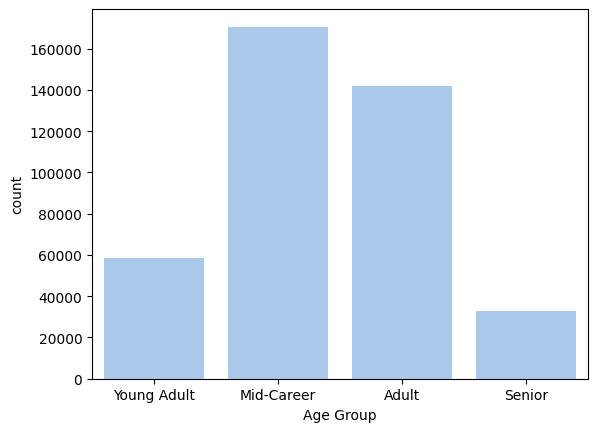

In [6]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.set_palette("pastel")

sns.countplot(data=df, x="Age Group")
plt.show()

In [7]:
def classify_interaction_frequency(last_interaction):
    if 0 < last_interaction <= 7:
        return "Highly Active"
    elif 7 < last_interaction <= 15:
        return "Active"
    elif last_interaction > 15:
        return "Dormant"

df["Interaction Frequency"] = df["Last Interaction"].apply(classify_interaction_frequency)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group,Interaction Frequency
0,23.0,0.0,19.0,846.18,18.0,0.0,0,1,Young Adult,Dormant
1,19.0,1.0,26.0,149.04,10.0,1.0,0,1,Young Adult,Active
2,40.0,3.0,19.0,266.00,9.0,1.0,0,1,Mid-Career,Active
3,44.0,2.0,27.0,662.00,16.0,1.0,1,0,Mid-Career,Dormant
4,49.0,9.0,9.0,857.00,8.0,1.0,0,1,Mid-Career,Active


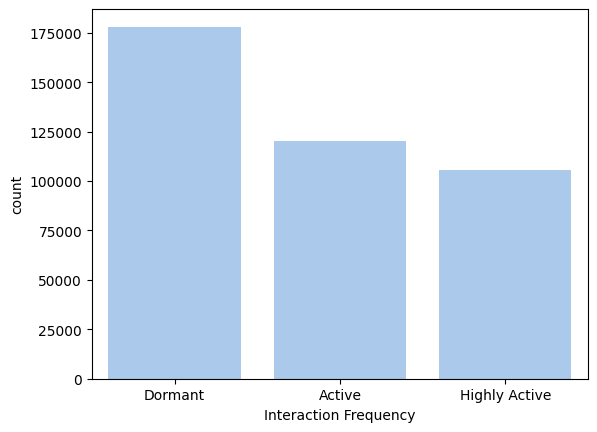

In [8]:
sns.countplot(data=df, x="Interaction Frequency")
plt.show()

In [9]:
age_mapping = {
    'Young Adult': 0,
    'Adult': 1,
    'Mid-Career': 2,
    'Senior': 3
}

interaction_mapping = {
    'Highly Active': 0,
    'Active': 1,
    'Dormant': 2
}

df["Age Group"] = df["Age Group"].apply(lambda age: age_mapping[age])
df["Interaction Frequency"] = df["Interaction Frequency"].apply(lambda age: interaction_mapping[age])
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group,Interaction Frequency
0,23.0,0.0,19.0,846.18,18.0,0.0,0,1,0,2
1,19.0,1.0,26.0,149.04,10.0,1.0,0,1,0,1
2,40.0,3.0,19.0,266.00,9.0,1.0,0,1,2,1
3,44.0,2.0,27.0,662.00,16.0,1.0,1,0,2,2
4,49.0,9.0,9.0,857.00,8.0,1.0,0,1,2,1


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_no_label = df.drop(["Churn", "Female"], axis=1)
df_no_label = pd.DataFrame(scaler.fit_transform(df_no_label), columns=df_no_label.columns)
df_no_label.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency
0,-1.317667,-1.222065,0.651239,0.921373,0.394475,0.895356,-1.722856,1.003122
1,-1.633098,-0.903046,1.479306,-1.922014,-0.534765,0.895356,-1.722856,-0.218334
2,0.022917,-0.265009,0.651239,-1.444976,-0.650920,0.895356,0.668872,-0.218334
3,0.338349,-0.584028,1.597601,0.170168,0.162165,-1.116875,0.668872,1.003122
4,0.732638,1.649101,-0.531715,0.965503,-0.767075,0.895356,0.668872,-0.218334


In [11]:
df = df_no_label.join(df["Churn"])
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency,Churn
0,-1.317667,-1.222065,0.651239,0.921373,0.394475,0.895356,-1.722856,1.003122,0.0
1,-1.633098,-0.903046,1.479306,-1.922014,-0.534765,0.895356,-1.722856,-0.218334,1.0
2,0.022917,-0.265009,0.651239,-1.444976,-0.650920,0.895356,0.668872,-0.218334,1.0
3,0.338349,-0.584028,1.597601,0.170168,0.162165,-1.116875,0.668872,1.003122,1.0
4,0.732638,1.649101,-0.531715,0.965503,-0.767075,0.895356,0.668872,-0.218334,1.0


In [12]:
import os

os.makedirs("../data/preprocessed", exist_ok=True)
df.to_csv("../data/preprocessed/train.csv", index=False)